## Xenium QC Report Module

### Please enter the following information before running the notebook
1. uuid_list: If you are starting from a list of UUIDs, please add a comma separated list of UUIDs, where each UUID is within quotes.
2. project_short_name: Name of the project store where the aggregated file can be uploaded
3. title description for aggregated file output name
4. pdf_file_name: Filename for the pdf report of all visualizations
5. all_qc_report_path

In [4]:
############################################################################################
# Please provide the following 3 input:                                                    #
# (1) uuid_list: in the following format                                                   #                                                                                    #
#      ["967a55cb-9b98-4926-b997-9586cce2e47a", "7660b4c5-d248-462a-a455-53d5d580a32d"]    #                                                                                    #
# (2) project_short_name: this is the short name of the project you want to                #
#      upload the file to, i.e., fh1_bmp, fh1_data                                         #
# (3) title_description: this is a description of this file to be uploaded, i.e.,          #
#      xenium qc report for run name XP-01134-01135_060527.                                #
############################################################################################
#uuid_list = ["8bb5984b-c355-4e10-9c17-9151e2c31267", "953362b5-4717-486e-bac1-7760a89e241d"]
#project_short_name = 'aifiDevTest'
#title_description = 'Xenium QC report for run name XP-01134-01135_060527'
uuid_list = []
project_short_name = ''
title_description = 'EXP-02059-02060'
pdf_file_name = 'Xenium_qc_report.pdf'

## If starting by assembling metrics csv files in a folder, please enter complete path to the folder.
## This folder should contain ONLY the metrics_summary csv files that you wish to QC, please remove any other files.
all_qc_report_path = '/home/workspace/xenium/qc/EXP-02059-02060/csvs'

output_dir = "/home/workspace/xenium/qc/EXP-02059-02060"

In [2]:
#!pip install hisepy

In [2]:
import pandas as pd
import os
import datetime
import logging
import hisepy

### Option 1: Starting from metrics summary file UUIDs

In [4]:
def set_logging(log_dir, log_file_name):
    logger = logging.getLogger(__name__)
    fhandler = logging.FileHandler(filename=os.path.join(log_dir, log_file_name), mode='a')
    formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
    fhandler.setFormatter(formatter)
    logger.addHandler(fhandler)
    logger.setLevel(logging.DEBUG)
    return logger

In [5]:
def download_files(logger, input_dir, uuid_list):
    #####################################################
    # This function downloads the files per uuids and   #
    # move the files to specified input folder          #
    #####################################################

    # Apply hisepy.reader.cache_files function to download the specified sample files #
    hisepy.reader.cache_files(uuid_list)

    # Move all the uuid folders from 'cache' folder to the 'input_dir'
    for each_uuid in uuid_list:
        logger.info("Copying file {0} from /home/jupyter/cache/ to {1}/......".format(each_uuid, input_dir))
        os.system('cp -r /home/jupyter/cache/{0} {1}/.'.format(each_uuid, input_dir))

In [6]:
def create_aggregated_qc(logger, input_dir, output_dir, uuid_list):
    #################################################################
    # This function loops through the uuid list, parses QC report   #
    # for each sample, and aggregates the QC metrics into one .csv  #
    #################################################################

    run_name_list = []
    df_to_concat = []
    for each_uuid in uuid_list:
        # Check if the expected file is present and make sure the size is non-zero #
        per_qc_report_path = os.path.join(input_dir, each_uuid, 'metrics_summary.csv')

        if os.path.exists(per_qc_report_path):
            if os.path.getsize(per_qc_report_path) > 0:
                logger.info("Found QC report for uuid {0}".format(each_uuid))
                df_per_sample_qc = pd.read_csv(per_qc_report_path)
                df_to_concat.append(df_per_sample_qc)
                
				# Fetch Run ID #
                run_name = df_per_sample_qc.iloc[0]['run_name']
                run_name_list.append(run_name)
            else:
                # If the QC metrics file has zero size, skip it and print a warning #
                logger.warning("QC report for uuid {0} is empty, skipping it".format(each_uuid))
        else:
            logger.warning("Could not find QC report for uuid {0}, skipping it".format(each_uuid))

    df_aggregated_qc_report = pd.concat(df_to_concat)
    
	# Check if all the samples have the same 'run_name', if so, use this run_name as the prefix of the output qc report #
    if len(set(run_name_list))==1:
        run_name_prefix = run_name_list[0]
        output_qc_file_name = run_name_prefix + '_xenium_qc_report.csv'
    else:
        run_name_prefix = None
        output_qc_file_name = 'xenium_qc_report.csv'		

    # Write the aggregated QC report dataframe to a .CSV file #
    df_aggregated_qc_report.to_csv(os.path.join(output_dir, output_qc_file_name), index=False, header=True)

    return output_qc_file_name

In [7]:
def upload_output_to_hise(project_short_name, uuid_list, title_description, output_qc_file_name, current_timestamp):
	hisepy.upload_files(files=[os.path.join(output_dir, output_qc_file_name)], 
	                    project=project_short_name, 
	                    title=title_description,
	                    destination = '{0}/xenium_qc_report'.format(current_timestamp),
	                    input_file_ids=uuid_list)


In [8]:
# Create a folder with timestamp in the current working directory #
current_timestamp = datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
working_dir = os.path.join('/home/jupyter/execute_xenium_qc_module', current_timestamp)
if not os.path.exists(working_dir):
    os.makedirs(working_dir)

log_dir = os.path.join(working_dir, 'logs')
if not os.path.exists(log_dir):
    os.makedirs(log_dir)

input_dir = os.path.join(working_dir, 'input')
if not os.path.exists(input_dir):
    os.makedirs(input_dir)

output_dir = os.path.join(working_dir, 'output')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

logger = set_logging(log_dir, 'xenium_qc_report.log')

# If uuid_list is not provided by user, print following warning #
if uuid_list and project_short_name and title_description:
    download_files(logger, input_dir, uuid_list)
    output_qc_file_name = create_aggregated_qc(logger, input_dir, output_dir, uuid_list)
    title_description_with_timestamp = '{0}-{1}'.format(title_description, current_timestamp) 
    upload_output_to_hise(project_short_name, uuid_list, title_description_with_timestamp, output_qc_file_name, current_timestamp)
else:
    if not uuid_list:
        print("Warning: please provide uuid_list")
    if not project_short_name:
        print("Warning: please provide project_short_name")
    if not title_description:
        print("Warning: please provide title_description")

In [9]:
os.listdir(all_qc_report_path)

['output-XETG00195__0033792__TIS08308-001__20240711__221925_metrics_summary.csv',
 '.ipynb_checkpoints',
 'output-XETG00123__0034044__TIS02784-001-001__20240711__221220_metrics_summary.csv',
 'output-XETG00123__0034044__TIS02795-001-009__20240711__221220_metrics_summary.csv',
 'output-XETG00195__0033752__TIS08305-001__20240711__221925_metrics_summary.csv',
 'output-XETG00123__0027461__TIS06055-001-011__20240606__220427_metrics_summary.csv',
 'output-XETG00195__0033752__TIS08306-001__20240711__221925_metrics_summary.csv',
 'output-XETG00123__0027459__TIS06055-001-009__20240606__220427_metrics_summary.csv',
 'output-XETG00123__0034036__TIS02805-001-009__20240711__221220_metrics_summary.csv',
 'output-XETG00195__0033792__TIS08307-001__20240711__221925_metrics_summary.csv',
 'output-XETG00123__0027459__TIS06055-001-010__20240606__220427_metrics_summary.csv']

### Option 2: Starting from metrics summary file's location instead of UUIDs 
#### (please skip if Option 1 (UUID method) has been run)

In [5]:
### Enter the path to metrics summary csv files if not entered above
#all_qc_report_path = '/home/jupyter/xenium/csv/'

df_to_concat = []
run_name_list = []

if os.path.exists(all_qc_report_path):
    if os.path.getsize(all_qc_report_path) > 0:
        all_files = os.listdir(all_qc_report_path)

        # Filter for filenames ending with '.csv'
        csv_files = [filename for filename in all_files if filename.endswith('.csv')]
        for filename in csv_files:

            per_qc_report_path = os.path.join(all_qc_report_path, filename)

            df_per_sample_qc = pd.read_csv(per_qc_report_path)

            ## Get run names
            run_name = df_per_sample_qc.iloc[0]['run_name']
            run_name_list.append(run_name)

            df_to_concat.append(df_per_sample_qc)


    df_aggregated_qc_report = pd.concat(df_to_concat)
    
output_qc_file_name = 'xenium_qc_report.csv'		

# Write the aggregated QC report dataframe to a .CSV file #
df_aggregated_qc_report.to_csv(os.path.join(output_dir, output_qc_file_name), index=False, header=True)

### Setting up data for visualizations

In [6]:
plot_df = df_aggregated_qc_report.dropna(axis=1, how='any')
plot_df

,run_name,cassette_name,region_name,panel_name,panel_design_id,region_area,total_cell_area,total_high_quality_decoded_transcripts,fraction_transcripts_decoded_q20,nuclear_transcripts_per_100um2,...,median_transcripts_per_cell,thickness_transcripts_high_quality,stain_definition,segmented_cell_stain_frac,segmented_cell_boundary_frac,segmented_cell_interior_frac,segmented_cell_nuc_expansion_frac,segmented_cell_boundary_count,segmented_cell_interior_count,segmented_cell_nuc_expansion_count
0,output_corrected_TSS06403-005,EXP-02060,TSS06403-005,hother_1420g,abc123,3.554000e+07,5.651993e+06,25287150,0.834936,406.141576,...,131,6.280236,xenium_cell_segmentation_stains_v2,0.973452,0.314829,0.658623,0.026548,42087,88046,3549
0,output_corrected_TSS05029-004,EXP-02059,TSS05029-004,hother_1420g,abc123,3.256408e+07,6.383568e+06,28214795,0.823500,363.915301,...,132,5.786750,xenium_cell_segmentation_stains_v2,0.981328,0.272104,0.709223,0.018672,35936,93665,2466
0,output_corrected_TSS08944-007,EXP-02059,TSS08944-007,hother_1420g,abc123,1.927086e+07,7.116351e+06,106046445,0.820066,1401.992623,...,1063,5.432147,xenium_cell_segmentation_stains_v2,0.979535,0.799388,0.180147,0.020465,73670,16602,1886
0,output_corrected_TSS08944-008,EXP-02060,TSS08944-008,hother_1420g,abc123,1.489223e+07,4.746598e+06,77529144,0.845885,1580.161051,...,1254,5.871895,xenium_cell_segmentation_stains_v2,0.975301,0.833491,0.141811,0.024699,48595,8268,1440
0,output_corrected_TSS06403-004,EXP-02059,TSS06403-004,hother_1420g,abc123,2.991368e+07,5.653384e+06,23644197,0.834045,368.119846,...,119,6.696680,xenium_cell_segmentation_stains_v2,0.971637,0.312233,0.659405,0.028363,42207,89137,3834
0,output_corrected_TSS05029-005,EXP-02060,TSS05029-005,hother_1420g,abc123,3.343160e+07,6.813602e+06,31083741,0.818146,392.354061,...,142,6.944842,xenium_cell_segmentation_stains_v2,0.980678,0.229834,0.750844,0.019322,32283,105465,2714


In [7]:
run_name_list

['output_corrected_TSS06403-005',
 'output_corrected_TSS05029-004',
 'output_corrected_TSS08944-007',
 'output_corrected_TSS08944-008',
 'output_corrected_TSS06403-004',
 'output_corrected_TSS05029-005']

In [8]:
plot_df.columns

Index(['run_name', 'cassette_name', 'region_name', 'panel_name',
       'panel_design_id', 'region_area', 'total_cell_area',
       'total_high_quality_decoded_transcripts',
       'fraction_transcripts_decoded_q20', 'nuclear_transcripts_per_100um2',
       'decoded_transcripts_per_100um2',
       'adjusted_negative_control_probe_rate',
       'adjusted_negative_control_codeword_rate',
       'adjusted_genomic_control_probe_rate',
       'negative_control_probe_counts_per_control_per_cell',
       'genomic_control_probe_counts_per_control_per_cell',
       'estimated_number_of_false_positive_transcripts_per_cell',
       'estimated_number_of_false_positive_transcripts_per_cell_including_genomic_counts',
       'num_cells_detected', 'fraction_empty_cells', 'cells_per_100um2',
       'fraction_transcripts_assigned', 'median_genes_per_cell',
       'median_transcripts_per_cell', 'thickness_transcripts_high_quality',
       'stain_definition', 'segmented_cell_stain_frac',
       'segmented

In [9]:
import matplotlib.pyplot as plt
import plotly.express as px
from matplotlib.backends.backend_pdf import PdfPages

In [10]:
colors = [
'#9e0142','#d53e4f','#f46d43','#fdae61','#fee08b','#e6f598','#abdda4','#66c2a5','#3288bd','#5e4fa2'
]

In [11]:
col = ['#d53e4f','#66c2a5','#5e4fa2']

In [12]:
pdf_pages = PdfPages(pdf_file_name)

## Number of cells detected

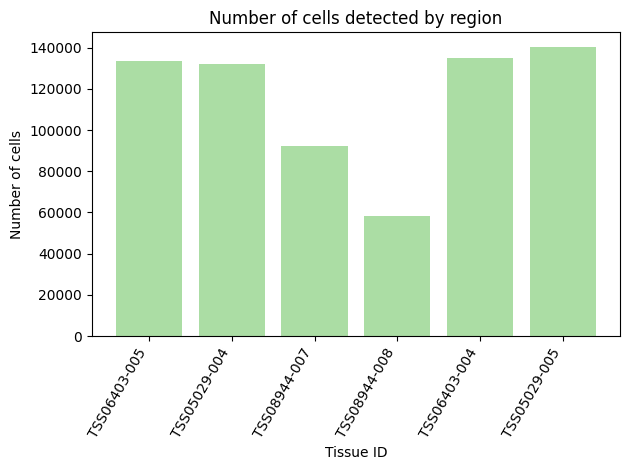

In [13]:
plt.bar(plot_df['region_name'], plot_df['num_cells_detected'], color= colors[6])
plt.xticks(rotation=60, ha = 'right')

# Add labels and title
plt.xlabel('Tissue ID')
plt.ylabel('Number of cells')
plt.title('Number of cells detected by region')

plt.tight_layout()

pdf_pages.savefig()

## Transcripts and Genes per Tissue

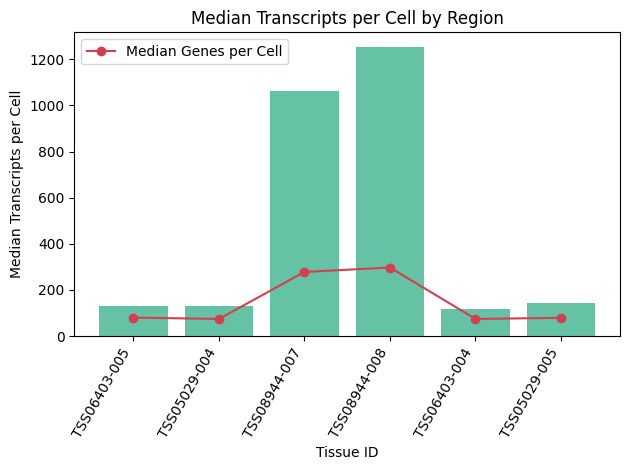

In [15]:
plt.bar(plot_df['region_name'], plot_df['median_transcripts_per_cell'], color= colors[7])
plt.xticks(rotation=60, ha = 'right')
plt.plot(plot_df['region_name'], plot_df['median_genes_per_cell'], color=colors[1], marker='o', label='Median Genes per Cell')

# Add labels and title
plt.xlabel('Tissue ID')
plt.ylabel('Median Transcripts per Cell')
plt.title('Median Transcripts per Cell by Region')
plt.legend()

plt.tight_layout()

pdf_pages.savefig()

## Estimated False Positive Transcripts

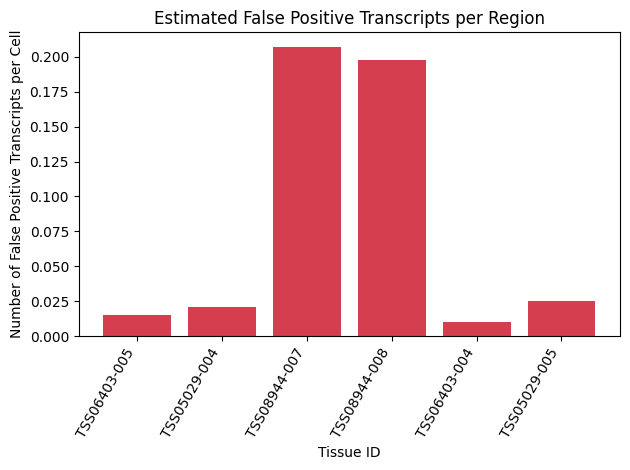

In [16]:
plt.bar(plot_df['region_name'], plot_df['estimated_number_of_false_positive_transcripts_per_cell'], color= colors[1])
plt.xticks(rotation=60, ha = 'right')
# Add labels and title
plt.xlabel('Tissue ID')
plt.ylabel('Number of False Positive Transcripts per Cell')
plt.title('Estimated False Positive Transcripts per Region')

plt.tight_layout()

pdf_pages.savefig()

## Decoded Transcripts

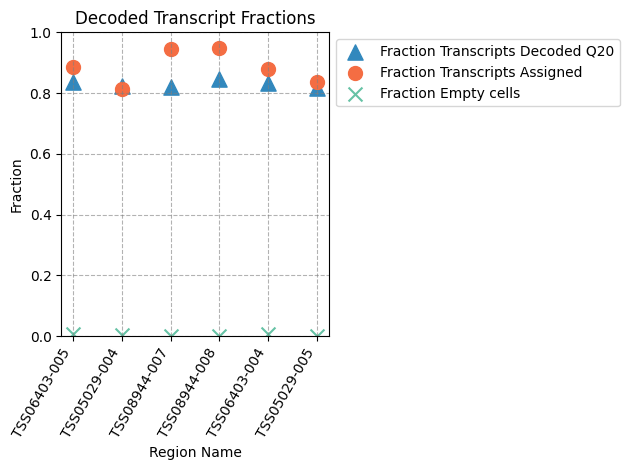

In [17]:
plt.scatter(plot_df['region_name'], plot_df['fraction_transcripts_decoded_q20'], color=colors[8], label='Fraction Transcripts Decoded Q20', marker='^', s=120)
plt.scatter(plot_df['region_name'], plot_df['fraction_transcripts_assigned'], color=colors[2], label='Fraction Transcripts Assigned', marker='o', s=100)
plt.scatter(plot_df['region_name'], plot_df['fraction_empty_cells'], color=colors[7], label='Fraction Empty cells', marker='x', s=100)
plt.xticks(rotation=60, ha='right')
plt.xlabel('Region Name')
plt.ylabel('Fraction')
plt.title('Decoded Transcript Fractions')
plt.ylim(0, 1)

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle='--', color='gray', alpha=0.6)

# Adjust layout to fit everything
plt.tight_layout()

pdf_pages.savefig()

## Cells per 100um sq

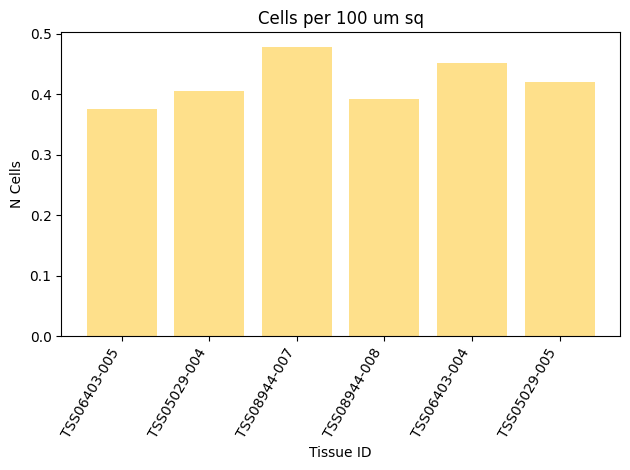

In [18]:
plt.bar(plot_df['region_name'], plot_df['cells_per_100um2'], color= colors[4])
plt.xticks(rotation=60, ha = 'right')

# Add labels and title
plt.xlabel('Tissue ID')
plt.ylabel('N Cells')
plt.title('Cells per 100 um sq')

plt.tight_layout()

pdf_pages.savefig()

## Segmentation Fractions and Counts

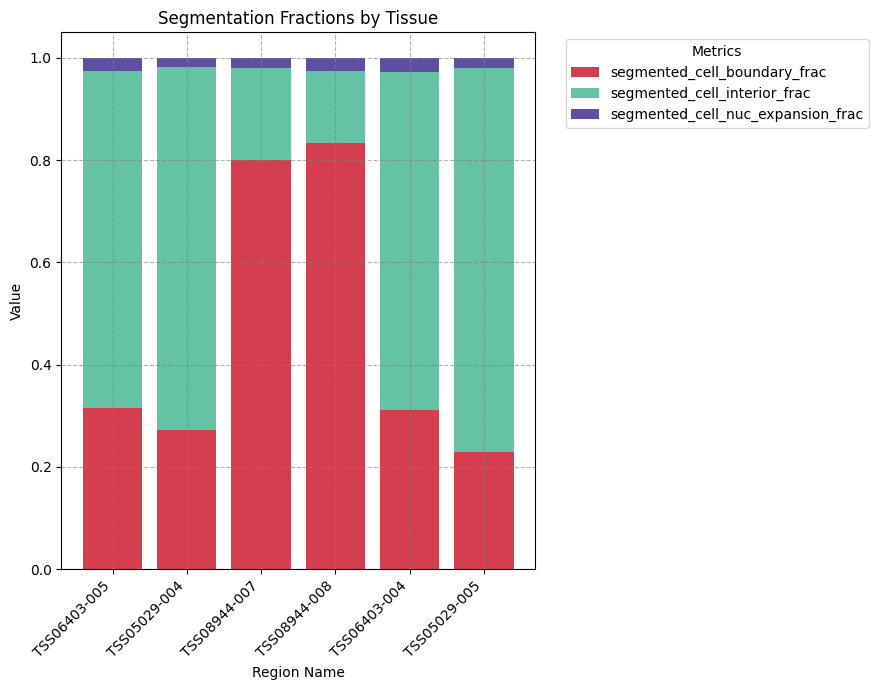

In [19]:
regions = plot_df['region_name']
values = plot_df[['segmented_cell_boundary_frac', 
                  'segmented_cell_interior_frac', 
                  'segmented_cell_nuc_expansion_frac']]

fig, ax = plt.subplots(figsize=(9, 7))

# Initialize the bottom position for stacking
bottoms = [0] * len(plot_df)

# Plot each stack
for i, column in enumerate(values.columns):
    ax.bar(
        regions,
        values[column],
        bottom=bottoms,
        label=column,
        color=col[i]
    )
    # Update the bottom position
    bottoms = [bottom + val for bottom, val in zip(bottoms, values[column])]

# Add labels and title
ax.set_xlabel('Region Name')
ax.set_ylabel('Value')
ax.set_title('Segmentation Fractions by Tissue')
ax.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Show grid
plt.grid(True, linestyle='--', color='gray', alpha=0.6)

# Adjust layout to fit everything
plt.tight_layout()

pdf_pages.savefig()

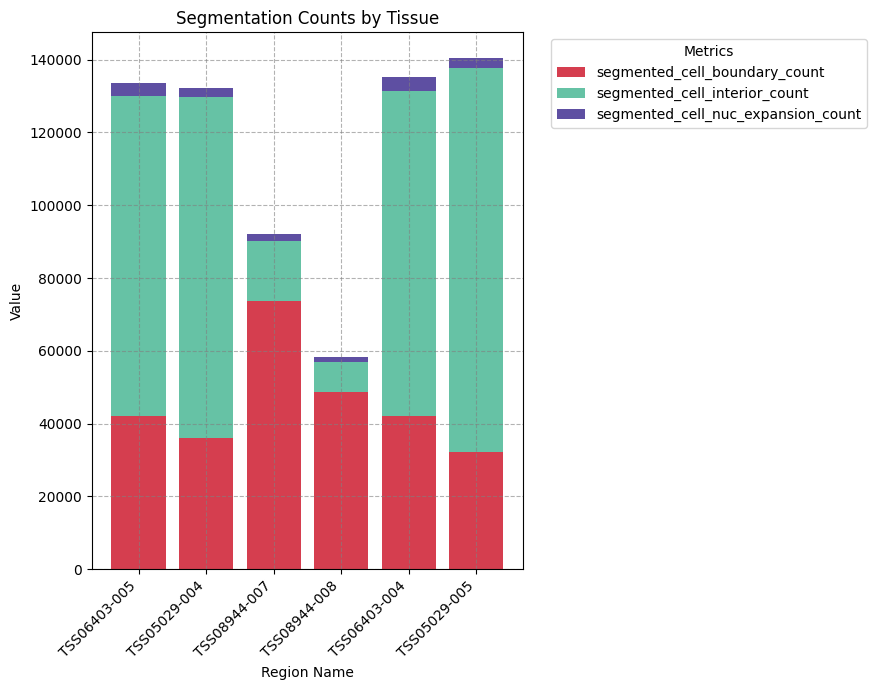

In [20]:
regions = plot_df['region_name']
values = plot_df[['segmented_cell_boundary_count', 
                  'segmented_cell_interior_count', 
                  'segmented_cell_nuc_expansion_count']]

fig, ax = plt.subplots(figsize=(9, 7))

# Initialize the bottom position for stacking
bottoms = [0] * len(plot_df)

# Plot each stack
for i, column in enumerate(values.columns):
    ax.bar(
        regions,
        values[column],
        bottom=bottoms,
        label=column,
        color=col[i]
    )
    # Update the bottom position
    bottoms = [bottom + val for bottom, val in zip(bottoms, values[column])]

# Add labels and title
ax.set_xlabel('Region Name')
ax.set_ylabel('Value')
ax.set_title('Segmentation Counts by Tissue')
ax.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Show grid
plt.grid(True, linestyle='--', color='gray', alpha=0.6)

# Adjust layout to fit everything
plt.tight_layout()

pdf_pages.savefig()

## Median Transcripts per panel

/tmp/ipykernel_19473/424606040.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


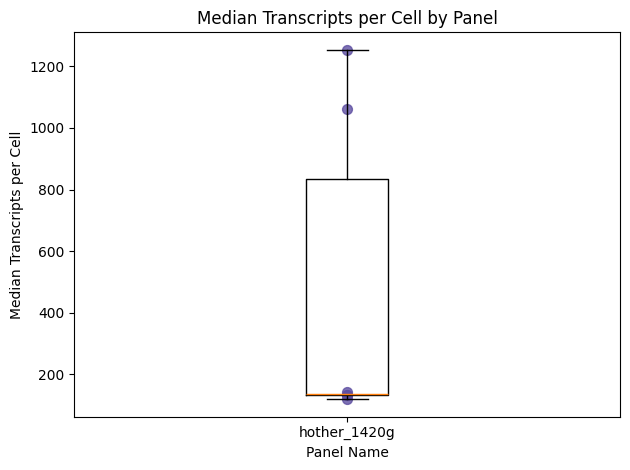

In [21]:
# Create the box plot
box = plt.boxplot(
    [plot_df[plot_df['panel_name'] == panel]['median_transcripts_per_cell'] for panel in plot_df['panel_name'].unique()],
    labels=plot_df['panel_name'].unique(),
    showfliers=False 
)
# Overlay individual points
for i, panel in enumerate(plot_df['panel_name'].unique(), start=1):
    # Extract data for the current panel
    panel_data = plot_df[plot_df['panel_name'] == panel]['median_transcripts_per_cell']
    
    # Scatter plot on top of box plot
    plt.scatter(
        [i] * len(panel_data),  
        panel_data,             
        color= colors[9],          
        alpha=0.8,           
        s=50,                 
        label=f'Points in {panel}' if i == 1 else "_" 
    )
# Labeling
plt.xlabel('Panel Name')
plt.ylabel('Median Transcripts per Cell')
plt.title('Median Transcripts per Cell by Panel')

plt.tight_layout()

pdf_pages.savefig()

In [22]:

plt.close()
pdf_pages.close()